# Titanic Survival Analysis

## Data Analysis with Python

**Internship:** Data Science & Analysis with Python – Task 2

This project analyzes the Titanic dataset to identify factors that influenced passenger survival using Python, Pandas, Matplotlib and Seaborn.

## **Project Objective**

The objective of this project is to analyze the Titanic dataset and identify the key factors that influenced passenger survival. Using Python and popular data analysis libraries such as Pandas, Matplotlib and Seaborn, the project focuses on data cleaning, exploratory data analysis and visualization to uncover meaningful patterns and present data-driven insights.

## **Dataset Description**

The Titanic dataset contains information about passengers aboard the RMS Titanic. Each row represents one passenger, while each column provides specific details such as demographic information, ticket details and survival status.

In [94]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
# load dataset
df = pd.read_csv('/content/titanic.csv')

In [96]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [97]:
df.shape

(891, 12)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Dataset Information

This step provides details about data types, non-null values and overall dataset structure.

# Columns Description

| Column | Description |
|---------|-------------|
| PassengerId | Unique identification number assigned to each passenger. |
| Survived | Survival status (0 = Did Not Survive, 1 = Survived). |
| Pclass | Passenger ticket class (1 = First Class, 2 = Second Class, 3 = Third Class). |
| Name | Full name of the passenger. |
| Sex | Gender of the passenger. |
| Age | Age of the passenger in years. |
| SibSp | Number of siblings or spouses traveling with the passenger. |
| Parch | Number of parents or children traveling with the passenger. |
| Ticket | Passenger's ticket number. |
| Fare | Ticket fare paid by the passenger. |
| Cabin | Cabin number assigned to the passenger. |
| Embarked | Port where the passenger boarded the ship (C = Cherbourg, Q = Queenstown, S = Southampton). |

In [99]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Statistical Summary

Descriptive statistics help understand the distribution of numerical features such as Age and Fare.

In [100]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Missing Value Analysis

Real-world datasets often contain missing values. Identifying them is the first step before cleaning the data.

In [101]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [102]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [103]:
df.drop('Cabin', axis=1, inplace=True)

## **Cleaning Summary**

- Missing values in Age were replaced with the median.
- Missing values in Embarked were replaced with the most frequent value.
- Cabin was removed because most values were missing.
- The dataset is now ready for analysis.

## **Exploratory Data Analysis (EDA)**

### What is the overall survival distribution of passengers?

This analysis shows how many passengers survived and how many did not survive the Titanic disaster.

In [104]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [105]:
# percentage of passengers survived

survival_rate = df['Survived'].value_counts(normalize=True) * 100
print(survival_rate)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


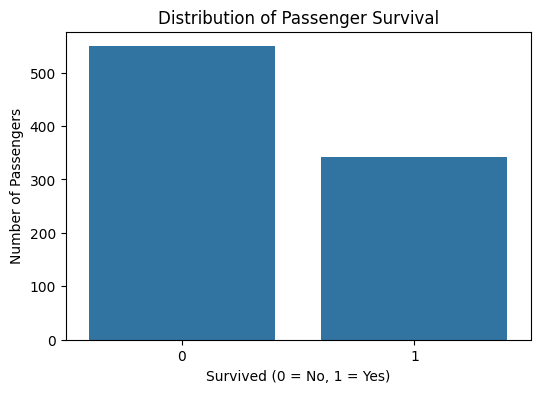

In [106]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Survived')

plt.title("Distribution of Passenger Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Out of 891 passengers, more people did not survive than survived. The survival rate is approximately 38%, indicating that most passengers lost their lives in the disaster.

### Did gender influence survival chances?

This analysis compares the survival rates of male and female passengers.

In [107]:
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


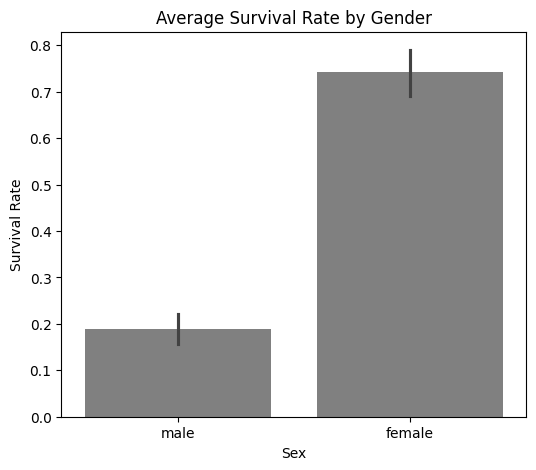

In [108]:
plt.figure(figsize=(6,5))

sns.barplot(df, x='Sex', y='Survived', color='gray')

plt.title("Average Survival Rate by Gender")
plt.ylabel("Survival Rate")

plt.show()

### Insight

Female passengers had a significantly higher survival rate than male passengers. This supports the historical "women and children first" evacuation policy followed during the disaster.

### How were passengers distributed across ticket classes?

This visualization shows the number of passengers traveling in each ticket class.

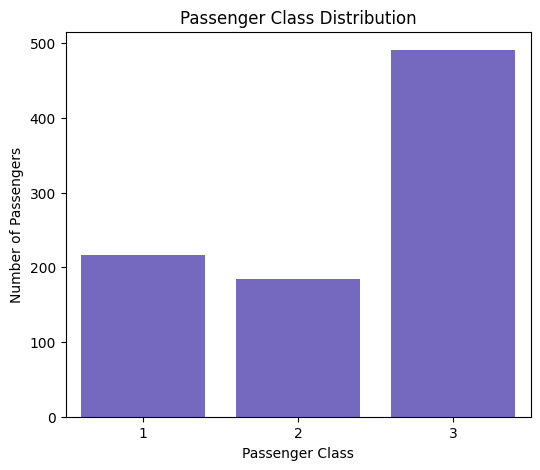

In [109]:
plt.figure(figsize=(6,5))

sns.countplot(df, x='Pclass', color='slateblue')

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

### Observation
Third Class had the highest number of passengers, while Second Class had the fewest.

### Did passenger class affect survival?

This visualization examines whether ticket class had an impact on the likelihood of survival.

In [110]:
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


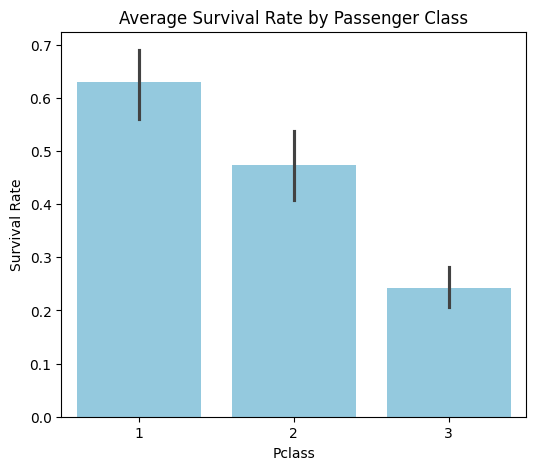

In [111]:
plt.figure(figsize=(6,5))

sns.barplot(df, x='Pclass', y='Survived', color='skyblue')

plt.title("Average Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Insight

Passengers traveling in First Class had a much higher chance of survival compared to those in Third Class, suggesting that ticket class played an important role during evacuation.

### What is the age distribution of passengers?

Understanding the age distribution helps identify the age groups represented in the dataset.

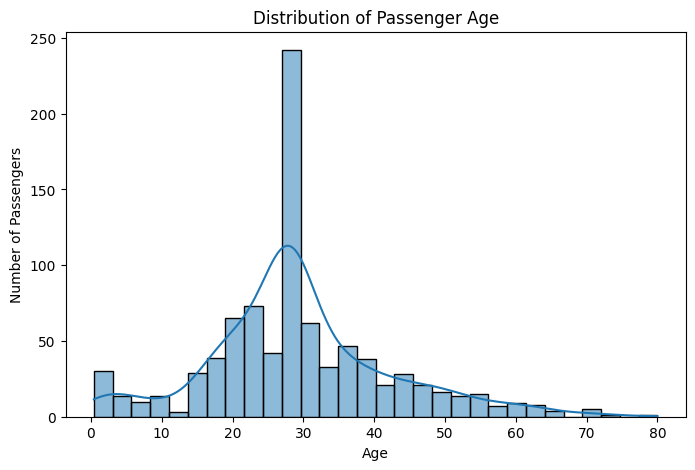

In [112]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Most passengers were between 20 and 40 years old. Very young children and elderly passengers represented a smaller proportion of the dataset.

### Which age group had the highest survival rate?

Passengers are grouped by age to compare survival rates across different age categories.

In [113]:
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [114]:
df['Age_Group'].value_counts()

,count
Age_Group,
Young Adult,510
Adult,195
Teen,95
Child,69
Senior,22


In [115]:
df.groupby('Age_Group', observed=False)['Survived'].mean()

,Survived
Age_Group,
Child,0.579710
Teen,0.410526
Young Adult,0.352941
Adult,0.400000
Senior,0.227273


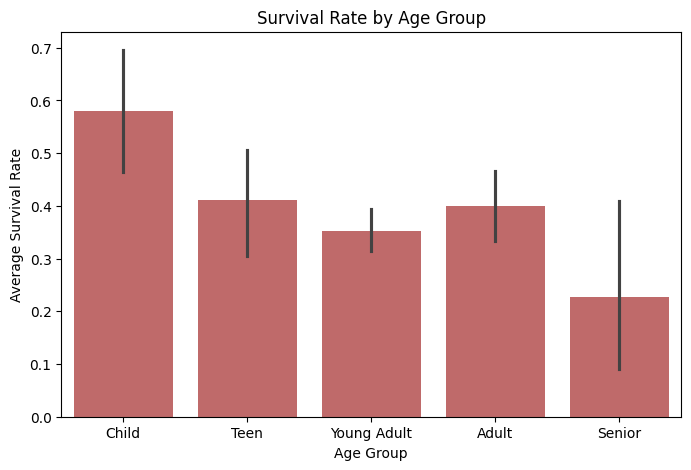

In [116]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Age_Group',
    y='Survived',
    order=['Child','Teen','Young Adult','Adult','Senior'],
    color = 'indianred'
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Survival Rate")

plt.show()

### Insight

Children generally showed a better survival rate than adults and senior passengers, indicating that younger passengers were given higher evacuation priority.

### Which port did most passengers board from?

This analysis examines the distribution of passengers based on their embarkation port.

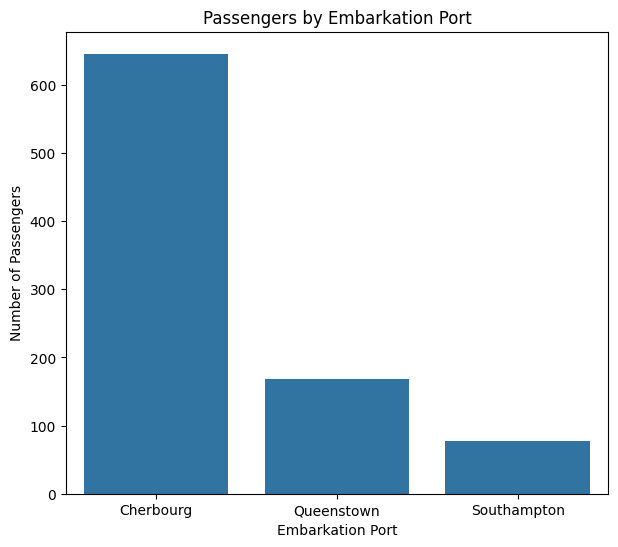

In [117]:
plt.figure(figsize=(7,6))

sns.countplot(x='Embarked', data=df)

plt.title("Passengers by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of Passengers")

plt.xticks(
    ticks=[0, 1, 2],
    labels=['Cherbourg', 'Queenstown', 'Southampton']
)

plt.show()

### Observation

Most passengers boarded the Titanic from Southampton, followed by Cherbourg and Queenstown.

### How are passenger fares distributed?

This visualization explores the overall distribution of ticket fares.

In [118]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


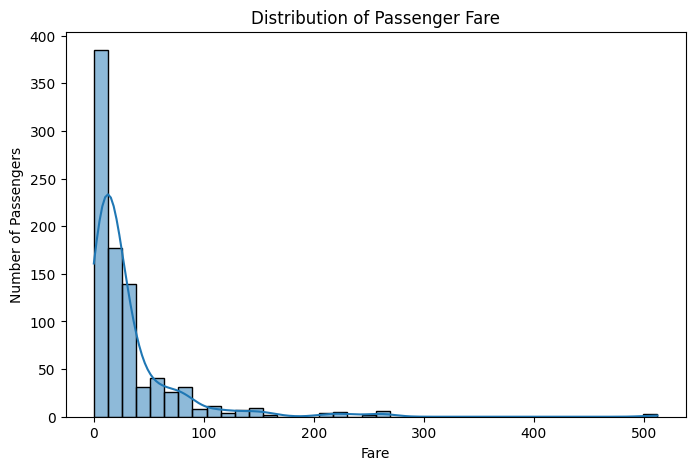

In [119]:
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=40, kde=True)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

Passenger fares are positively skewed, with most travelers paying lower fares and only a few paying premium ticket prices.

### Does family size affect survival?

A new feature, Family Size, is created to explore whether traveling with family influenced survival.

In [120]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

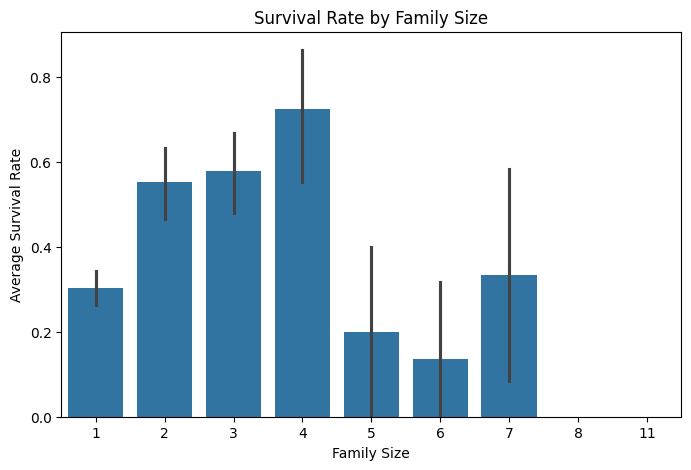

In [121]:
plt.figure(figsize=(8,5))

sns.barplot(x='Family_Size', y='Survived', data=df)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Average Survival Rate")

plt.show()

### Insight

Passengers traveling with small families appeared to have better survival chances than those traveling alone or in very large families.

### Correlation heatmap

It helps identify relationships between numerical variables in the dataset.

In [122]:
numeric_df = df.select_dtypes(include=['number'])

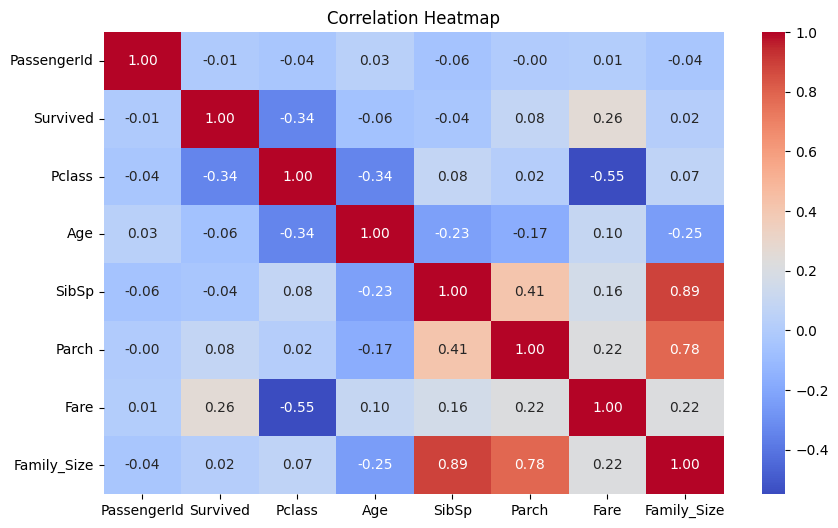

In [123]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

The heatmap indicates that Fare and Passenger Class are associated with survival. Family-related features also show strong relationships with each other.

### **Outlier detection**

Box plots are used to identify unusual values in Age and Fare.

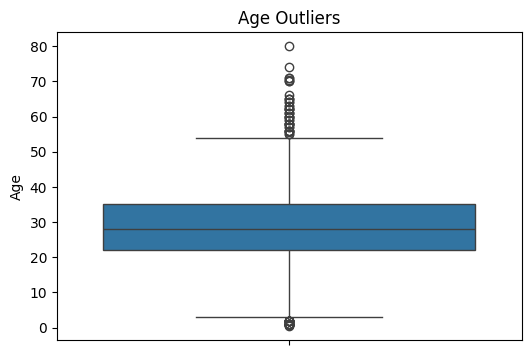

In [124]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df['Age'])

plt.title("Age Outliers")

plt.show()

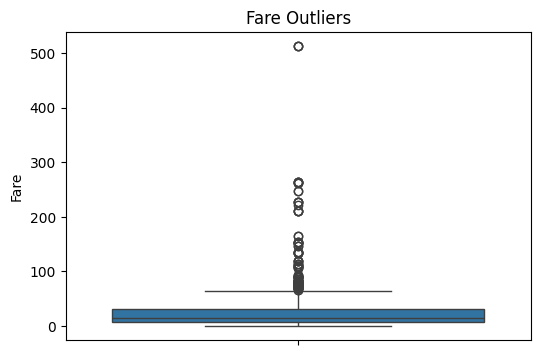

In [125]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df['Fare'])

plt.title("Fare Outliers")

plt.show()

### Observation

Outliers are present in both Age and Fare. Since these values represent actual passengers, they were retained rather than removed.

## **Key Findings**

- Around 38% of passengers survived, while the remaining passengers did not survive.
- Female passengers had a considerably higher survival rate than male passengers.
- Passengers traveling in First Class were more likely to survive than those in Second and Third Class.
- Most passengers were between 20 and 40 years of age.
- Children generally showed better survival rates compared to older passengers.
- Southampton was the most common embarkation port among passengers.
- Higher ticket fares were often associated with higher survival rates.
- Most passengers traveled either alone or with a small family.
- The correlation analysis suggests that passenger class and fare were among the strongest factors related to survival.
- Although outliers were present in Age and Fare, they represented genuine passenger records and were retained in the analysis.

## **Conclusion**

This project explored the Titanic dataset to understand the factors that influenced passenger survival. The analysis began with data cleaning to handle missing values, followed by exploratory data analysis using statistical summaries and visualizations.

The results indicate that survival was strongly influenced by gender, passenger class, age, and ticket fare. Female passengers and First Class travelers had the highest survival rates, while Third Class passengers were less likely to survive. Children also showed better survival outcomes compared to older passengers.

Overall, this project demonstrates the complete workflow of a data analysis task, including data preprocessing, visualization, feature engineering, and interpretation of results. It highlights how meaningful insights can be extracted from raw data using Python, Pandas, Matplotlib, and Seaborn, making the dataset easier to understand and supporting informed, data-driven conclusions.